# Baseline Model — Logistic Regression

Tujuan:
- Membangun model baseline sederhana sebelum mencoba model lebih kompleks
- Evaluasi menggunakan AUC (bukan accuracy) karena dataset sangat imbalance
  (TARGET: 0 = 282,686 | 1 = 24,825)

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report, 
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
data_path = project_root / "data" / "processed" / "feature_table_final.csv"

df = pd.read_csv(data_path)
print(df.shape)
df.head()

(307507, 100)


,SK_ID_CURR,TARGET,CODE_GENDER,age_years,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,employment_years,AMT_CREDIT,AMT_ANNUITY,...,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,298488,0,0,59.1,0,2.0,37800.0,4.5,675000.0,28597.5,...,False,False,False,False,False,False,False,False,True,False
1,298493,1,1,45.7,1,3.0,112500.0,11.9,1078200.0,38331.0,...,False,False,False,False,False,False,False,False,True,False
2,298523,0,1,51.4,0,1.0,202500.0,10.0,605439.0,31041.0,...,False,False,False,False,False,False,False,False,False,False
3,298524,0,0,56.3,0,2.0,180000.0,4.5,803907.0,29002.5,...,False,False,False,False,False,False,False,False,True,False
4,298530,0,0,39.4,1,3.0,90000.0,7.9,247275.0,17716.5,...,False,False,False,False,False,False,False,False,False,False


In [3]:
# SK_ID_CURR bukan fitur, hanya identifier -> harus dibuang dari X
X = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())
print("y distribution (%):\n", y.value_counts(normalize=True) * 100)

X shape: (307507, 98)
y distribution:
 TARGET
0    282682
1     24825
Name: count, dtype: int64
y distribution (%):
 TARGET
0    91.927013
1     8.072987
Name: proportion, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # penting! supaya proporsi TARGET 0/1 tetap sama di train & test
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train TARGET distribution:\n", y_train.value_counts(normalize=True))
print("Test TARGET distribution:\n", y_test.value_counts(normalize=True))

Train shape: (246005, 98)
Test shape: (61502, 98)
Train TARGET distribution:
 TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64
Test TARGET distribution:
 TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # penting! kompensasi untuk data imbalance
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [7]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.7628


              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56537
           1       0.17      0.69      0.27      4965

    accuracy                           0.70     61502
   macro avg       0.57      0.70      0.54     61502
weighted avg       0.90      0.70      0.77     61502



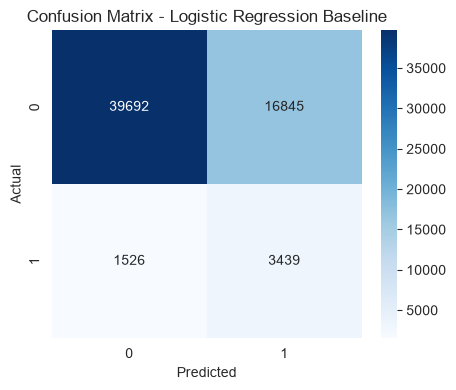

In [8]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

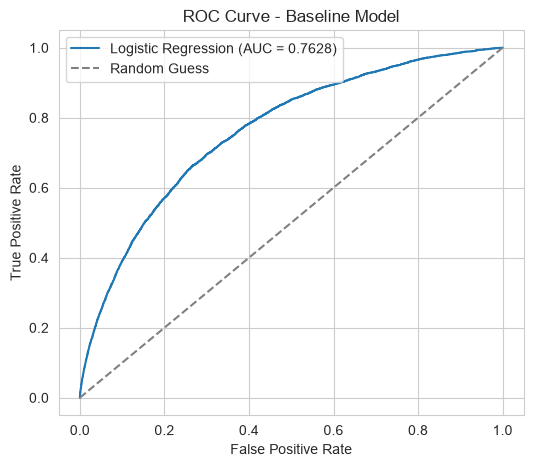

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Model")
plt.legend()
plt.show()

## Ringkasan Baseline Model

- Model: Logistic Regression dengan class_weight='balanced'
- AUC Score: (isi manual setelah lihat hasil)
- Ini adalah baseline — target berikutnya adalah mencoba model yang lebih 
  kompleks (LightGBM/XGBoost) untuk meningkatkan performa (Milestone 23).

# Advanced Model — LightGBM

Tujuan:
- Meningkatkan performa dari baseline Logistic Regression (AUC 0.7628)
- Menggunakan LightGBM (gradient boosting) yang biasanya lebih kuat untuk data tabular
- Tetap menangani class imbalance

In [10]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

data_path = project_root / "data" / "processed" / "feature_table_final.csv"
df = pd.read_csv(data_path)
print(df.shape)

(307507, 100)


In [11]:
X = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (246005, 98)
Test shape: (61502, 98)


In [12]:
# LightGBM punya parameter scale_pos_weight, mirip class_weight tapi versi rasio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

Scale pos weight: 11.39


In [13]:
model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

model_lgb.fit(X_train, y_train)

print("LightGBM training selesai.")

LightGBM training selesai.


In [14]:
y_pred_proba_lgb = model_lgb.predict_proba(X_test)[:, 1]
y_pred_lgb = model_lgb.predict(X_test)

auc_score_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
print(f"LightGBM AUC Score: {auc_score_lgb:.4f}")
print(f"Baseline (Logistic Regression) AUC Score: 0.7628")
print(f"Improvement: {(auc_score_lgb - 0.7628):.4f}")

LightGBM AUC Score: 0.7783
Baseline (Logistic Regression) AUC Score: 0.7628
Improvement: 0.0155


              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56537
           1       0.19      0.68      0.29      4965

    accuracy                           0.74     61502
   macro avg       0.58      0.71      0.57     61502
weighted avg       0.90      0.74      0.79     61502



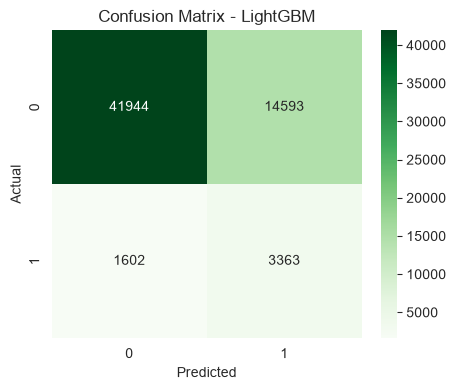

In [15]:
print(classification_report(y_test, y_pred_lgb))

cm_lgb = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

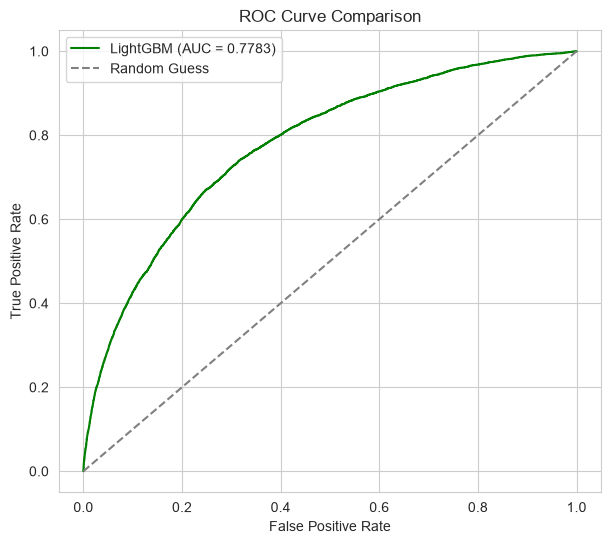

In [16]:
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_proba_lgb)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC = {auc_score_lgb:.4f})", color="green")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

C:\Users\christovel kevin .m\AppData\Local\Temp\ipykernel_3640\805696567.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")


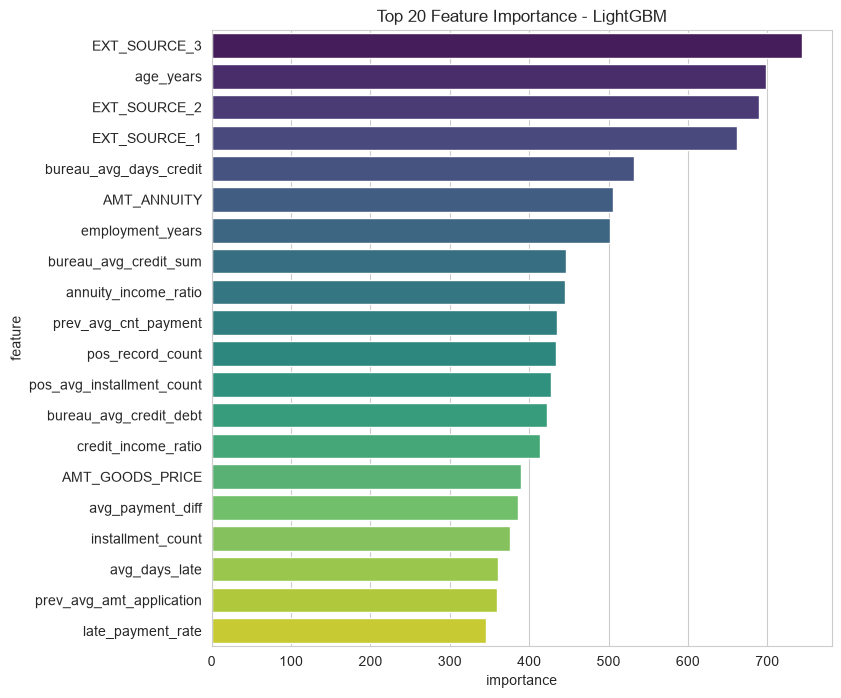

In [17]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model_lgb.feature_importances_
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(8, 8))
sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
plt.title("Top 20 Feature Importance - LightGBM")
plt.show()

## Ringkasan Perbandingan Model

| Model | AUC Score |
|---|---|
| Logistic Regression (baseline) | 0.7628 |
| LightGBM | 0.7783 |



# Model Interpretability — SHAP

Tujuan:
- Memahami kontribusi tiap fitur terhadap prediksi risiko SECARA INDIVIDUAL per customer
- Ini jadi dasar fitur "Top Contributing Factors" di Decision Support System (Streamlit nanti)

In [18]:
# LightGBM native SHAP values via pred_contrib=True
# Ini menghitung TreeSHAP secara langsung, tanpa perlu install package 'shap'

X_test_sample = X_test.sample(n=2000, random_state=42)

# pred_contrib menghasilkan array (n_samples, n_features + 1)
# kolom terakhir adalah base_value (expected value)
shap_contrib = model_lgb.booster_.predict(X_test_sample, pred_contrib=True)

feature_names = X_test_sample.columns.tolist()
base_value = shap_contrib[:, -1][0]   # base value sama untuk semua baris
shap_values = shap_contrib[:, :-1]     # kontribusi per fitur, tanpa kolom base_value

print("Shape SHAP values:", shap_values.shape)
print("Base value:", base_value)

Shape SHAP values: (2000, 98)
Base value: -0.6278950457691989


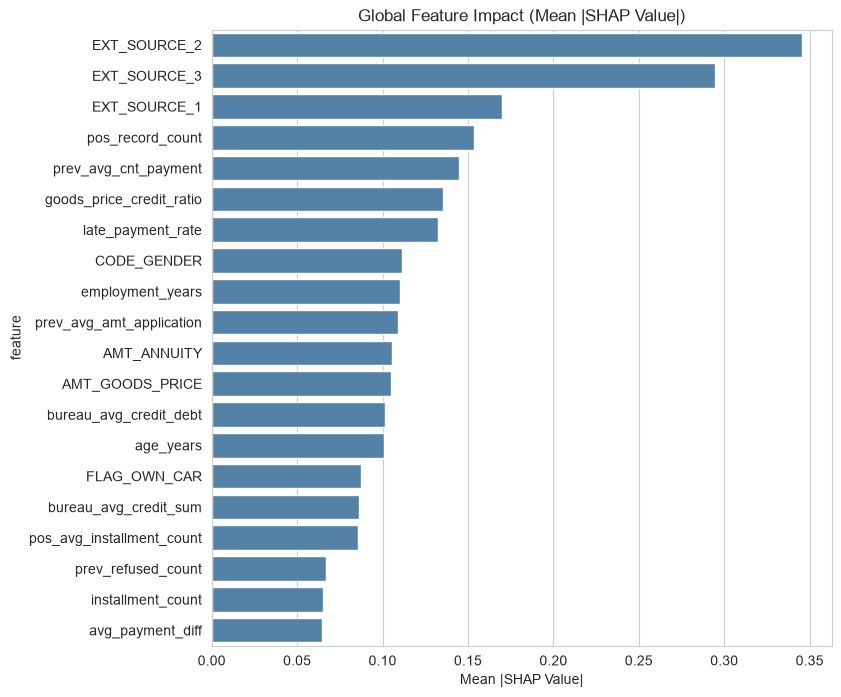

In [19]:
# Rata-rata absolute SHAP value per fitur -> mirip summary plot SHAP
mean_abs_shap = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).head(20)

plt.figure(figsize=(8, 8))
sns.barplot(data=mean_abs_shap, x="mean_abs_shap", y="feature", color="steelblue")
plt.title("Global Feature Impact (Mean |SHAP Value|)")
plt.xlabel("Mean |SHAP Value|")
plt.show()

In [20]:
sample_idx = 0
sample_customer = X_test_sample.iloc[[sample_idx]]

pred_proba = model_lgb.predict_proba(sample_customer)[0, 1]
print(f"Predicted default probability: {pred_proba:.2%}")

print(f"\nBase value (rata-rata prediksi model): {base_value:.4f}")
print(f"Total SHAP contribution untuk customer ini: {shap_values[sample_idx].sum():.4f}")

Predicted default probability: 14.83%

Base value (rata-rata prediksi model): -0.6279
Total SHAP contribution untuk customer ini: -1.1199


In [21]:
def get_top_contributing_factors(shap_values_row, feature_names, top_n=5):
    """
    Mengembalikan top N fitur yang paling berkontribusi terhadap prediksi,
    beserta arah kontribusinya (meningkatkan atau menurunkan risiko).
    """
    contributions = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_values_row
    })
    
    contributions["abs_value"] = contributions["shap_value"].abs()
    contributions = contributions.sort_values("abs_value", ascending=False).head(top_n)
    
    contributions["direction"] = contributions["shap_value"].apply(
        lambda x: "Meningkatkan Risiko" if x > 0 else "Menurunkan Risiko"
    )
    
    return contributions[["feature", "shap_value", "direction"]]


top_factors = get_top_contributing_factors(
    shap_values[sample_idx], 
    feature_names, 
    top_n=5
)
print(top_factors)

                  feature  shap_value            direction
15           EXT_SOURCE_3   -0.412238    Menurunkan Risiko
5        employment_years   -0.215563    Menurunkan Risiko
1               age_years    0.155878  Meningkatkan Risiko
53      late_payment_rate   -0.146826    Menurunkan Risiko
19  bureau_avg_credit_sum    0.140324  Meningkatkan Risiko


## Ringkasan SHAP Analysis

- Menggunakan TreeSHAP native dari LightGBM (pred_contrib=True), tanpa dependency tambahan.
- Hasil mengonfirmasi EXT_SOURCE_1/2/3 dan age_years sebagai fitur paling berpengaruh 
  secara global, konsisten dengan feature_importance LightGBM dan korelasi SQL.
- Fungsi `get_top_contributing_factors()` akan digunakan di FastAPI (Milestone 26)
  untuk menjelaskan tiap prediksi individual di Decision Support System.

# Save Final Model

In [22]:
import joblib

model_dir = project_root / "data" / "models"
model_dir.mkdir(parents=True, exist_ok=True)

# Simpan model
joblib.dump(model_lgb, model_dir / "credit_risk_model.pkl")

# Simpan juga daftar kolom fitur (URUTAN PENTING, harus sama persis saat prediksi nanti)
joblib.dump(list(X.columns), model_dir / "feature_columns.pkl")

print("Model dan feature columns berhasil disimpan.")
print("Jumlah fitur:", len(X.columns))

Model dan feature columns berhasil disimpan.
Jumlah fitur: 98


In [23]:
import sys
sys.path.append(str(project_root))

from src.models.predict import predict_credit_risk

# Ambil 1 contoh baris asli dari test set sebagai input dummy
sample_input = X_test.iloc[0].to_dict()

result = predict_credit_risk(sample_input)

print("Probability:", result["probability"])
print("Risk Category:", result["risk_category"])
print("Recommendation:", result["recommendation"])
print("\nTop Factors:")
for f in result["top_factors"]:
    print(f)

Probability: 0.2783
Risk Category: Medium Risk
Recommendation: Manual Review

Top Factors:
{'feature': 'employment_years', 'shap_value': 0.21873166500293753, 'direction': 'Meningkatkan Risiko'}
{'feature': 'AMT_ANNUITY', 'shap_value': 0.18531169539831877, 'direction': 'Meningkatkan Risiko'}
{'feature': 'EXT_SOURCE_3', 'shap_value': -0.1850600278886181, 'direction': 'Menurunkan Risiko'}
{'feature': 'goods_price_credit_ratio', 'shap_value': -0.18487111590312055, 'direction': 'Menurunkan Risiko'}
{'feature': 'FLAG_OWN_CAR', 'shap_value': -0.17234872289047656, 'direction': 'Menurunkan Risiko'}
